# GIN and FiLM training with unknown cell fate

**Role:** Training.

Train masked-fate GIN models, size-conditioned FiLM models, or both across an explicit depth/width/seed/fold grid. All data filters, targets, model choices and training parameters are specified here; this notebook neither reads settings from another notebook nor requires a reference training run. The exclusive fate panel gains a separate `fate_missing` flag, distinguishing observed unassigned cells from cells whose identity is hidden.

Each architecture has a matched 0% masking control and positive masking-rate variants. Fit and save a global baseline for every outer fold, optionally residualize targets, train on inner fitting organoids and stop on intact inner-validation MSE. Reserve the outer validation organoids for reported MSE and downstream benchmarks. Save models, outer/inner membership, exact prepared data, preprocessing and settings under `training_results/fate_masking_training/`. Analysis notebooks load these artifacts with `AnalysisRun`; no training is performed during analysis.


The current configuration belongs to the exclusive aligned-lineage paper study. All-cell and retained-lineage-only physical-unit MSE/MAE, and legacy budded-region plots, are evaluated in the separate paper notebooks. Original identities are retained for evaluation even when their input channels are omitted.

Memory-bounded execution: ACTIVE_FOLDS can select one fold per process and RESUME_RUN continues the same model catalog. Fitted inputs from earlier folds are not accumulated. The complete marker is written only when every requested checkpoint exists.

In [ ]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/models/gnn.py").is_file())  # Locate the repository from the notebook’s working directory.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
ROOT = PROJECT_ROOT  # Repository root used to resolve data and result paths.

## Setup and training choices

The settings below define a self-contained experiment. `model_types=['gin']` uses ordinary GIN aggregation; `['film']` conditions aggregation on log cell count; specify both to train matched versions. `depths` is a list, so a single run can scan 0–4 or any other supported depths. At depth 0 there are no message-passing/FiLM layers. `global_features` specifies what the head receives; FiLM requires `log_num_cells` in that vector. These choices are independent of masking, which adds the missingness flag to either architecture.


In [ ]:
import copy, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import attach_metadata_to_graphs, load_aux_metadata_for_dir, load_marker_names_from_dir
from src.data.filters import (filter_graphs_by_blacklist, load_graph_blacklist_from_dir,
    filter_graphs_by_timepoints, filter_graphs_by_sphericity, filter_graphs_by_numeric_metadata)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors
from src.data.marker_exclusivity import exclusive_markers, EXCLUSIVITY_RULES
from src.training.preparation import prepare_fold
from src.models.gnn import GINCurvature, SizeFiLMGINCurvature
from src.models.size_models import seed_all
from src.inference.predict import predict_targets
from src.artifacts.bundle import save_bundle, graph_membership
from src.artifacts.provenance import workflow_fingerprint
from src.artifacts.paths import training_run_path
from src.analysis.metrics.evaluation import compare_baseline_mse
from src.training.progress import TrainingProgress
from src.models.fate_masking import with_missing_fate_input
from src.data.fate_masking import encode_fates, ObservedFateAdapter
from src.training.masking import MaskTrainingConfig, inner_split, train_mask_model
from src.artifacts.runs import AnalysisRun
from src.training.preparation import load_matching_fold


In [ ]:
# Execution switches
RUN_TRAINING = True  # Enable fitting and saving new model checkpoints.

SETTINGS = dict(
    # Run identity
    tag='paper_exclusive_20261006_153255',  # Optional purpose label; letters, digits, underscores and hyphens.

    # Dataset and targets
    dataset='after_cleanup',  # Source dataset folder under training_data/.
    target_indices=[0],  # Target columns to predict; [0] selects Gaussian curvature.

    # Data filters
    timepoints=['day4', 'day4p5', 'day4p5-more'],  # Shared cohort timepoints for train/validation; None keeps all, or use a list of labels.
    blacklist=True,  # Exclude organoids listed in the dataset blacklist.
    sphericity_max=0.94,  # Maximum retained sphericity; None disables this filter where supported.
    complexity_min=None,  # Minimum retained complexity; None disables this filter.
    interpolate_outliers=True,  # Replace extreme targets using neighboring cells.
    outlier_quantiles=[0.005, 0.995],  # Lower and upper quantiles defining target outliers.

    # Fate encoding
    exclusive_markers=True,  # Apply ordered rules so each cell has at most one fate.

    # Model grid
    model_types=['gin'],  # Choose gin, film, or both; every model uses the complete fate panel.
    depths=[2],  # Message-passing depths to train; use [0, 1, 2, 3, 4] for a depth scan.
    hidden_dims=[128],  # Hidden widths to compare in the model grid.
    seeds=[42],  # Model initialization and training seeds to compare.

    # Data splits
    n_folds=5,  # n_folds=1: single holdout; larger values: organoid folds.
    val_fraction=0.2,  # Fraction of organoids held out when n_folds=1.
    split_seed=42,  # Random seed for organoid train/validation membership.

    # Target residualization
    residualize=False,  # Subtract the always-trained baseline from targets; False keeps original targets.
    baseline_features=['log_num_cells', 'log_surface_area', 'log_volume', 'log_volume_over_area'],  # Global features used only by the baseline model.

    # Model parameters
    film_hidden_dim=16,  # Width of the log-count FiLM conditioning network.
    global_features=['log_num_cells', 'log_surface_area', 'log_volume', 'log_volume_over_area'],  # Global columns appended to the prediction head.
    dropout=0.1,  # Probability of hidden-feature dropout during training.
    norm='batch',  # Hidden normalization: batch, layer, or none.
    residual=True,  # Enable residual connections within the GNN.

    # Training hyperparameters
    lr=0.0003,  # Optimizer learning rate.
    weight_decay=0.0001,  # AdamW weight-decay coefficient.
    batch_size=128,  # Number of graphs or subgraphs per batch.
    max_epochs=500,  # Maximum optimization epochs per fitted model.
    patience=30,  # Early-stopping patience, in epochs.
    num_workers=0,  # DataLoader worker processes; 0 loads in the main process.
    grad_clip=2.,  # Maximum gradient norm; None disables clipping.

    # Fate masking and inner early stopping
    rates=[0., .02],  # Include 0% control and at least one positive masking probability.
    masked_loss_weight=.5,  # Weight of masked-pass loss; the intact-pass weight is 1 minus this value.
    inner_val_fraction=.15,  # Fraction of outer-training organoids reserved for early stopping.
    inner_split_seed=8123,  # Seed shared by every architecture/rate within a fold.

    # Gaussian prediction loss and auxiliary edge penalty
    edge_loss_weight=0.2,  # Weight of the auxiliary edge-consistency penalty.
    edge_loss_params=dict(
        weighted=False,  # Weight edge penalties by the target difference.
        alpha=2.,  # Exponent controlling edge-loss weights.
        normalize_by='graph_std',  # Scale used to normalize the edge penalty.
        clip_weight=4.,  # Maximum weight assigned to one edge penalty.
    ),  # Options for computing the auxiliary edge penalty.

    # Baseline training
    baseline_hidden_dim=64,  # Hidden width of the global-only baseline.
    baseline_max_epochs=2000,  # Maximum training epochs for the global baseline.
    baseline_patience=30,  # Baseline early-stopping patience, in epochs.

)  # Explicit run configuration, saved alongside the models.

# Runtime
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Use CUDA when available, otherwise CPU.

# Shared fitted preprocessing
PREPROCESSING_RUN = '/home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/gin_depth_training/paper_exclusive_20261006_153255_20261006_153321'  # Set by the study runner to its completed main run; None fits fresh preprocessing.

# Bounded execution and resume
ACTIVE_FOLDS = None  # None runs all folds; [0] runs just fold 0 in this process.
RESUME_RUN = None  # Existing run directory; complete checkpoints are reused.
RUN_REGIONAL_EVALUATION = False  # Paper regional evaluation is in the separate analysis notebook.

# Paths and outputs
RUN_DIR = Path(RESUME_RUN) if RESUME_RUN else training_run_path(ROOT, 'fate_masking_training', SETTINGS['tag'])  # New run under training_results/<notebook>/<tag>_<timestamp>.

# Regional evaluation (annotations only; never model inputs)
REGION_SETTINGS = dict(
    crypt_max=.8,  # Crypt body: nearest normalized distance s < this boundary.
    neck_max=1.2,  # Qualified neck: crypt_max <= s <= neck_max; beyond is the villus proxy.
    neck_config=dict(
        minimum_crypt_cells=10,  # Assigned cells within s <= 1 required per crypt.
        minimum_relative_depth=.05,  # Minimum circumference trough depth relative to C(1).
        plateau_max_range=.10,  # Maximum relative circumference variation for a flat section.
        plateau_max_slope=.25,  # Maximum absolute relative slope of a flat section.
        plateau_exit_rise=.10,  # Required circumference rise after a flat section.
    ),
)

# Progress display
SHOW_PROGRESS = True  # Show one persistent panel for models, epochs and completed tasks.
PRINT_EPOCHS = False  # Also print each epoch; False keeps the training output compact.


## Load and filter the cohort

Load the source dataset and apply the single shared timepoint selection before any train/validation splitting. Every active filter prints kept/total organoids and retained fractions by dataset/timepoint. Apply the ordered exclusivity rules to the full fate panel, retaining unassigned cells as observed identities. The current masking benchmarks require exclusive fates, so this notebook checks that setting explicitly.

Optional target outlier interpolation retains the existing cohort-level procedure. Baseline fitting, global standardization and target scaling are fitted separately inside each outer training fold below; no preprocessing is copied from a previously trained model.


In [ ]:
if not SETTINGS['exclusive_markers']:
    raise ValueError('This masking workflow currently requires exclusive_markers=True.')
data_dir = ROOT/'training_data'/SETTINGS['dataset']  # Dataset directory supplying graphs and metadata.
graphs = load_graph_dataset_from_dir(str(data_dir))
attach_metadata_to_graphs(graphs, load_aux_metadata_for_dir(str(data_dir)), exclude_keys=None)
graphs = filter_graphs_by_timepoints(graphs, SETTINGS['timepoints'], print_summary=True)
graphs = select_graph_targets(graphs, target_indices=SETTINGS['target_indices'], inplace=False)
marker_names = load_marker_names_from_dir(str(data_dir))
if not marker_names or SETTINGS['target_indices'] != [0]:
    raise ValueError('This workflow requires named fate channels and scalar Gaussian curvature.')
if SETTINGS['blacklist']:
    graphs = filter_graphs_by_blacklist(graphs, load_graph_blacklist_from_dir(data_dir), print_summary=True)
if SETTINGS['sphericity_max'] is not None:
    graphs = filter_graphs_by_sphericity(graphs, max_sphericity=SETTINGS['sphericity_max'], print_summary=True)
if SETTINGS['complexity_min'] is not None:
    graphs = filter_graphs_by_numeric_metadata(graphs, key='complexity', min_value=SETTINGS['complexity_min'], allow_missing=False, print_summary=True)
if SETTINGS['exclusive_markers']:
    for g in graphs:
        g.x = torch.as_tensor(exclusive_markers(g.x.cpu().numpy(), marker_names), dtype=g.x.dtype)
if SETTINGS['interpolate_outliers']:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(graphs, clip_quantiles=SETTINGS['outlier_quantiles'])
else:
    outlier_info = None
assert len(graphs) >= 2 and len({g.organoid_str for g in graphs}) == len(graphs)
cohort = pd.DataFrame([dict(organoid_str=g.organoid_str, n_cells=len(g.x),
                          timepoint=str(g.meta.get('timepoint', 'unknown'))) for g in graphs])
print(f'Loaded {len(graphs)} organoids with {len(marker_names)} fate channels; the missingness flag is added during fitting.')


## Outer and inner organoid splits

Create either one holdout or the requested outer folds from this notebook's selected cohort. Within each outer training fold, reserve an inner group for early stopping. All depths, widths, architectures, masking rates and seeds share these memberships. Fit preprocessing and the baseline using outer-training organoids, as in the previous masking protocol; this includes the inner early-stopping group and is not fully nested preprocessing. The outer validation group remains excluded from all fitting.


In [ ]:
rng = np.random.default_rng(SETTINGS['split_seed'])
order = rng.permutation(len(graphs))
fold_count = SETTINGS['n_folds']
if not 1 <= fold_count <= len(graphs):
    raise ValueError('Invalid number of folds')
if fold_count == 1:
    if not 0 < SETTINGS['val_fraction'] < 1:
        raise ValueError('Invalid validation fraction')
    val_sets = [order[:max(1, min(len(order)-1, round(len(order)*SETTINGS['val_fraction'])))]]
else:
    val_sets = np.array_split(order, fold_count)
splits = []
for fold, val in enumerate(val_sets):
    split = dict(fold=fold, train_indices=np.setdiff1d(order, val).tolist(),
                 val_indices=val.tolist())
    if not split['train_indices'] or not split['val_indices']:
        raise ValueError(f'Empty cohort split: fold {fold}')
    splits.append(split)
membership = [dict(fold=s['fold'], **graph_membership(
    train=[graphs[i] for i in s['train_indices']], validation=[graphs[i] for i in s['val_indices']])) for s in splits]
TRAINING = MaskTrainingConfig(**{key: SETTINGS[key] for key in MaskTrainingConfig.__dataclass_fields__})
if not SETTINGS['model_types'] or set(SETTINGS['model_types']) - {'gin','film'}:
    raise ValueError("model_types must contain 'gin', 'film', or both.")
for name, minimum in [('depths',0),('hidden_dims',1),('seeds',0)]:
    values = SETTINGS[name]
    if (not values or len(set(values)) != len(values)
            or any(isinstance(v,bool) or not isinstance(v,int) or v < minimum for v in values)):
        raise ValueError(f'{name} must contain distinct integers >= {minimum}.')
if len(set(SETTINGS['model_types'])) != len(SETTINGS['model_types']):
    raise ValueError('Duplicate model families.')
if len(set(SETTINGS['global_features'])) != len(SETTINGS['global_features']):
    raise ValueError('Duplicate global features.')
if 'film' in SETTINGS['model_types'] and 'log_num_cells' not in SETTINGS['global_features']:
    raise ValueError('FiLM requires log_num_cells in global_features.')
inner_membership = []
for split in splits:
    outer = split['train_indices']
    fit_ids, early_ids = inner_split(len(outer), TRAINING.inner_val_fraction, TRAINING.inner_split_seed + split['fold'])
    split['fit_indices'] = [outer[i] for i in fit_ids]
    split['early_indices'] = [outer[i] for i in early_ids]
    inner_membership.append(dict(fold=split['fold'], **graph_membership(
        fit=[graphs[i] for i in split['fit_indices']],
        early_stopping=[graphs[i] for i in split['early_indices']],
        validation=[graphs[i] for i in split['val_indices']])))
model_count = len(splits) * len(SETTINGS['depths']) * len(SETTINGS['hidden_dims']) * len(SETTINGS['seeds']) * len(SETTINGS['model_types']) * len(TRAINING.rates)
print(f"Planned: {model_count} models, {len(splits)} baselines; families={SETTINGS['model_types']}, depths={SETTINGS['depths']}")


## Train and save the grid

Every optimizer step combines an intact and a randomly masked pass. Each node is hidden independently of fate, N, geometry and target; masks erase all fate channels and set `fate_missing=1`. An observed unassigned cell has all fate channels zero and flag 0. The 0% control also receives two passes, keeping optimizer-step counts and normalization/dropout passes matched. Additional mask-input weights start at zero, preserving the corresponding unmasked model's initial observed predictions. GIN and FiLM start with matched common weights, and each masking rate starts from the same architecture-specific initialization.

Select checkpoints by intact inner-validation transformed-target MSE. Always fit/save a baseline, even when `residualize=False`. The training run contains its own `settings.json`, outer `splits.json`, `inner_splits.json`, cohort snapshot, input bundles, model bundles, model catalog, metrics and progress log. Saved analysis inputs include the observed missingness flag, so reopening models does not depend on a training kernel or another run.

`RUN_TRAINING=False` stops before fitting. Enable it only after reviewing the settings. The persistent progress panel shows the active family/depth/fold/seed/rate and models remaining. A new timestamped output is created by the settings cell; existing runs are never overwritten.


In [ ]:
if not RUN_TRAINING:
    raise RuntimeError('Review settings, then set RUN_TRAINING=True to fit and save a new run.')
RUN_DIR.mkdir(parents=True, exist_ok=True)
(RUN_DIR/'models').mkdir(exist_ok=True)
(RUN_DIR/'inputs').mkdir(exist_ok=True)
(RUN_DIR/'history').mkdir(exist_ok=True)
SETTINGS['preprocessing_run'] = str(PREPROCESSING_RUN) if PREPROCESSING_RUN else None
if (RUN_DIR/'settings.json').exists() and json.loads((RUN_DIR/'settings.json').read_text()) != json.loads(json.dumps(SETTINGS)):
    raise ValueError('Resume settings differ from this saved run.')
(RUN_DIR/'settings.json').write_text(json.dumps(SETTINGS, indent=2))
(RUN_DIR/'splits.json').write_text(json.dumps(membership, indent=2))
(RUN_DIR/'inner_splits.json').write_text(json.dumps(inner_membership, indent=2))
(RUN_DIR/'exclusivity_rules.json').write_text(json.dumps(EXCLUSIVITY_RULES, indent=2))
cohort.to_csv(RUN_DIR/'cohort.csv', index=False)
provenance = workflow_fingerprint(ROOT/'experiments/training/fate_masking_training.ipynb')
if not (RUN_DIR/'cohort/manifest.json').exists():
    save_bundle(RUN_DIR/'cohort', dict(raw_graphs={g.organoid_str:g for g in graphs},
        all_marker_names=marker_names, settings=SETTINGS, outlier_info=outlier_info),
        splits=membership, provenance={'code_sha256':provenance})
records = json.loads((RUN_DIR/'models.json').read_text()) if (RUN_DIR/'models.json').exists() else []
scores = pd.read_csv(RUN_DIR/'validation_mse.csv').to_dict('records') if (RUN_DIR/'validation_mse.csv').exists() else []
baseline_rows = pd.read_csv(RUN_DIR/'baseline_validation_mse.csv').to_dict('records') if (RUN_DIR/'baseline_validation_mse.csv').exists() else []
histories = {}
completed_keys = {r['key'] for r in records}
active_splits = [s for s in splits if ACTIVE_FOLDS is None or s['fold'] in ACTIVE_FOLDS]
if not active_splits:
    raise ValueError('No folds selected.')
loss_settings = dict(LR=SETTINGS['lr'], WEIGHT_DECAY=SETTINGS['weight_decay'],
                     EDGE_LOSS_WEIGHT=SETTINGS['edge_loss_weight'], EDGE_LOSS_PARAMS=SETTINGS['edge_loss_params'])
with TrainingProgress(model_count, total_baselines=len(splits), show=SHOW_PROGRESS,
                      print_epochs=PRINT_EPOCHS, log_path=RUN_DIR/'training_progress.csv') as progress:
    for split in active_splits:
        fold = split['fold']
        seed_all(SETTINGS['split_seed'] + fold)
        with progress.task(kind='baseline', model='Global baseline', fold=fold):
            if PREPROCESSING_RUN is not None:
                prepared = load_matching_fold(PREPROCESSING_RUN, SETTINGS, graphs, membership, split['fold'])
            else:
                prepared = prepare_fold(graphs, split, global_features=SETTINGS['global_features'],
                    residualize=SETTINGS['residualize'], baseline_features=SETTINGS['baseline_features'],
                    baseline_kwargs=dict(hidden_dim=SETTINGS['baseline_hidden_dim'], max_epochs=SETTINGS['baseline_max_epochs'],
                        patience=SETTINGS['baseline_patience'], batch_size=SETTINGS['batch_size'], num_workers=SETTINGS['num_workers'],
                        train_kwargs=dict(device=DEVICE)))
        baseline_rows = [r for r in baseline_rows if r['fold'] != fold]
        baseline_rows.extend(dict(fold=fold, **row) for row in prepared['baseline_validation_mse'])
        pd.DataFrame(baseline_rows).to_csv(RUN_DIR/'baseline_validation_mse.csv', index=False)
        groups = prepared['groups']
        by_org = {g.organoid_str:g for g in groups['train']}
        fit = [by_org[org] for org in inner_membership[fold]['fit']]
        early = [by_org[org] for org in inner_membership[fold]['early_stopping']]
        observed_groups = copy.deepcopy(groups)
        for group in observed_groups.values():
            for graph in group:
                graph.x = encode_fates(graph.x)
        input_bundle = f'inputs/fold_{fold}_all_observed'
        if not (RUN_DIR/input_bundle/'manifest.json').exists():
            save_bundle(RUN_DIR/input_bundle, dict(**{k:v for k,v in prepared.items() if k != 'groups'},
                groups=observed_groups, marker_names=marker_names, input_encoding='fate_missing',
                inner_membership=inner_membership[fold]), splits=membership[fold], provenance={'code_sha256':provenance})
        for depth in SETTINGS['depths']:
            for width in SETTINGS['hidden_dims']:
                for seed in SETTINGS['seeds']:
                    kw = dict(n_markers=len(marker_names), hidden_dim=width, num_layers=depth,
                        dropout=SETTINGS['dropout'], norm=SETTINGS['norm'], residual=SETTINGS['residual'],
                        global_dim=len(SETTINGS['global_features']))
                    seed_all(seed)
                    common_model = GINCurvature(**kw)
                    for family in SETTINGS['model_types']:
                        if family == 'gin':
                            base_model = copy.deepcopy(common_model)
                        else:
                            seed_all(seed)
                            base_model = SizeFiLMGINCurvature(**kw, film_hidden_dim=SETTINGS['film_hidden_dim'],
                                size_feature_index=SETTINGS['global_features'].index('log_num_cells'))
                            base_model.load_state_dict(common_model.state_dict(), strict=False)
                        initial_model = with_missing_fate_input(base_model)
                        for rate in TRAINING.rates:
                            key = f'{family}_all_intact_d{depth}_h{width}_f{fold}_s{seed}_p{rate:g}'
                            if key in completed_keys:
                                continue
                            with progress.task(model=family, depth=depth, width=width, fold=fold, seed=seed, rate=rate):
                                model, history = train_mask_model(copy.deepcopy(initial_model), fit, early,
                                    loss_settings, TRAINING, rate=rate, seed=seed, device=DEVICE)
                                key = f'{family}_all_intact_d{depth}_h{width}_f{fold}_s{seed}_p{rate:g}'
                                record = dict(key=key, name=family, subset='all', signal='intact',
                                    depth=depth, hidden_dim=width, fold=fold, seed=seed, rate=float(rate),
                                    bundle=f'models/{key}', input_bundle=input_bundle)
                                progress.stage('Evaluating outer validation predictions and saving checkpoint')
                                y, mu, _ = predict_targets(groups['val'], ObservedFateAdapter(model),
                                    target_transform=prepared['transform'], device=DEVICE)
                                start = 0
                                for graph in groups['val']:
                                    stop = start + len(graph.x)
                                    scores.append(dict(**record, organoid_str=graph.organoid_str, n_cells=len(graph.x),
                                        mse=float(np.mean((np.asarray(y)[start:stop]-np.asarray(mu)[start:stop])**2)),
                                        mae=float(np.mean(np.abs(np.asarray(y)[start:stop]-np.asarray(mu)[start:stop])))))
                                    start = stop
                                save_bundle(RUN_DIR/record['bundle'], dict(model=model.cpu(), record=record,
                                    history=history, metrics={'inner_intact_mse_z':float(history.inner_intact_mse_z.min())}),
                                    splits=membership[fold], provenance={'code_sha256':provenance})
                                history.to_csv(RUN_DIR/'history'/f'{key}.csv', index=False)
                                histories[key] = history
                                records.append(record)
                                pd.DataFrame(records).to_json(RUN_DIR/'models.json', orient='records', indent=2)
                                compare_baseline_mse(scores, baseline_rows).to_csv(RUN_DIR/'validation_mse.csv', index=False)
    if len(records) == model_count:
        (RUN_DIR/'complete.json').write_text(json.dumps({'models':len(records)}))
print('Saved masking run:', RUN_DIR)


## Intact validation error

Compare MSE and MAE on all outer-validation cells for each masking rate. Curves show mean ± standard error across organoids; baseline errors use the same cells. Curvature and MAE are expressed in µm⁻² and MSE in µm⁻⁴.


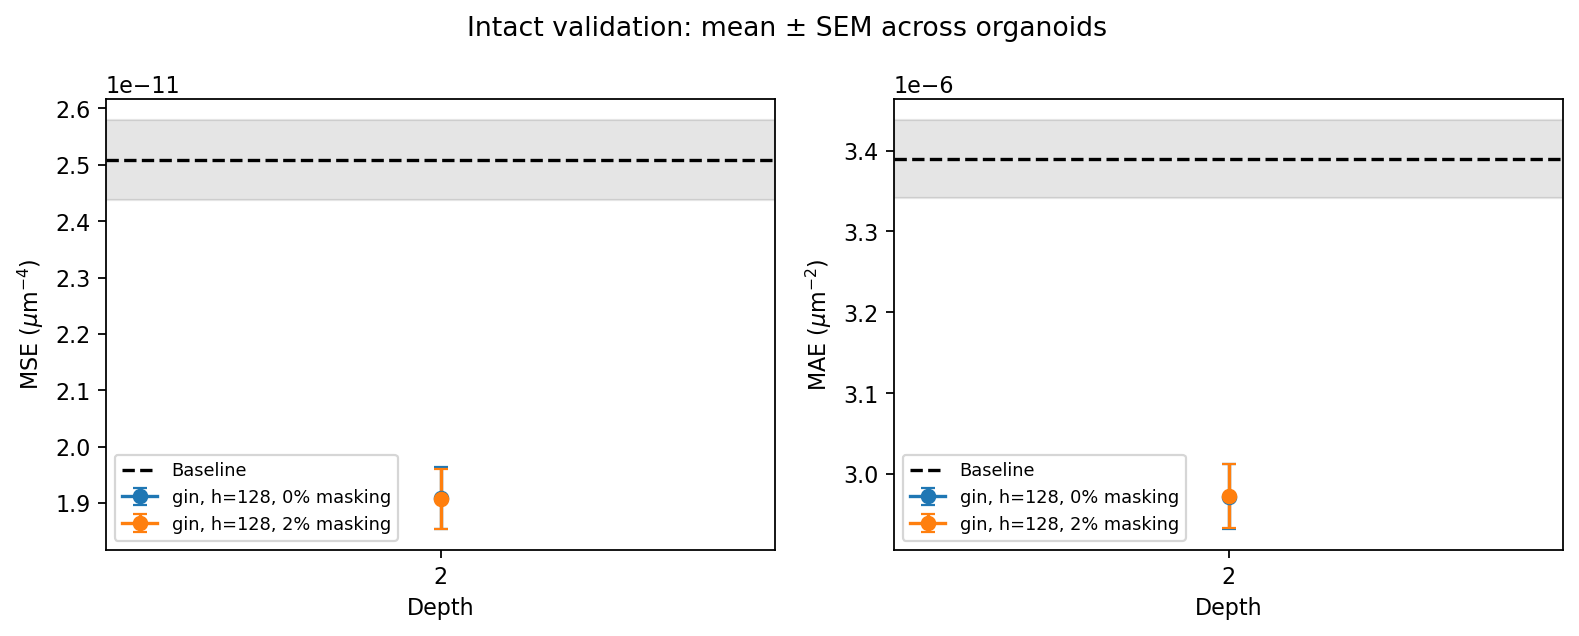

Completed 10 checkpoints across 5 folds.
Saved run: training_results/fate_masking_training/paper_exclusive_20261006_153255_20261007_101435


In [ ]:
validation = pd.read_csv(RUN_DIR/'validation_mse.csv')
baseline_table = pd.read_csv(RUN_DIR/'baseline_validation_mse.csv')
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric, scale, units in zip(axes, ['mse', 'mae'], [1e-8, 1e-4], [r'$\mu$m$^{-4}$', r'$\mu$m$^{-2}$']):
    for (family, width, rate), frame in validation.groupby(['name', 'hidden_dim', 'rate']):
        curve = frame.groupby('depth')[metric].agg(['mean', 'sem']) * scale
        ax.errorbar(curve.index, curve['mean'], yerr=curve['sem'], marker='o', capsize=3,
                    label=f'{family}, h={width}, {100*rate:g}% masking')
        ax.fill_between(curve.index, curve['mean']-curve['sem'], curve['mean']+curve['sem'], alpha=.15)
    base = baseline_table[metric] * scale
    ax.axhline(base.mean(), color='black', linestyle='--', label='Baseline')
    ax.axhspan(base.mean()-base.sem(), base.mean()+base.sem(), color='black', alpha=.1)
    ax.set(xlabel='Depth', ylabel=f'{metric.upper()} ({units})', xticks=sorted(validation.depth.unique()))
    ax.legend(fontsize=8)
fig.suptitle('Intact validation: mean ± SEM across organoids')
fig.tight_layout()
fig.savefig(RUN_DIR/'validation_errors_by_masking_rate.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved {len(records)} checkpoints; complete={(RUN_DIR/'complete.json').exists()}")


## Validation MSE by anatomical region and model depth

Reopen every saved checkpoint and evaluate its validation cells with the saved inputs, target transform, and baseline. Regions are derived directly from the source dataset's `d_crypts_graph` and `proj_vertex_ids` arrays and the original segmentation file named in each organoid's metadata. No tables from another experiment are loaded. Annotation settings are near the top of this notebook.

Use the **original nearest crypt**, checked against segmentation distances at each cell's projected vertex. Its circumference must have a supported local minimum or flat section near s=1 and enough assigned cells. Within these qualified territories, s<0.8 is crypt body, 0.8≤s≤1.2 is neck, and s>1.2 is the operational villus distance proxy (thresholds are configurable). Cells are never reassigned from an unqualified crypt to a farther qualified one. Missing annotations, no detected crypts, and unqualified territories remain separate in the support and score tables, rather than being labelled villus. Small undetected crypts remain a limitation of the source annotations.

Each panel shows physical-curvature MSE against depth for all saved folds, with separate curves for model variants and a dashed global baseline. First average squared errors within each organoid/region, then average repeated seeds or validation appearances within each organoid. Shading is ±1 SEM across organoids, conditional on the fitted models. A single trained depth produces a single point; SEM is absent with fewer than two organoids. Masking models are evaluated with all fates observed. Model inputs and fitting are unchanged.

Save per-organoid MSE, node-aligned region assignments and their source paths, support counts, summaries, settings, and the figure under the training run's `regional_evaluation/` folder. This section can also be rerun on an existing `RUN_DIR` without retraining, after restoring imports, `DEVICE`, and `REGION_SETTINGS`.


In [ ]:
if RUN_REGIONAL_EVALUATION:
    from src.analysis.spatial.regions import graph_regions
    from src.analysis.metrics.evaluation import prediction_table, regional_mse
    from src.plotting.depth_scan import plot_regional_mse
    
    regional_run = AnalysisRun(RUN_DIR)
    region_dataset_name = (regional_run.settings['dataset'] if regional_run.modern
                           else regional_run.legacy.settings['DATASET_NAME'])
    region_data_dir = ROOT / 'training_data' / region_dataset_name
    region_output = RUN_DIR / 'regional_evaluation'
    region_output.mkdir(exist_ok=True)
    (region_output / 'settings.json').write_text(json.dumps(
        dict(dataset=str(region_data_dir), **REGION_SETTINGS), indent=2))
    region_annotations = {}
    region_score_parts = []
    for regional_record in regional_run.records.to_dict('records'):
        selected = regional_run.select(regional_record['key'], device=DEVICE)
        for graph in selected['groups']['val']:
            if graph.organoid_str not in region_annotations:
                raw_graph = selected['raw_graphs'][graph.organoid_str]
                region_annotations[graph.organoid_str] = graph_regions(raw_graph, region_data_dir, **REGION_SETTINGS)
        annotations = pd.concat([region_annotations[g.organoid_str] for g in selected['groups']['val']], ignore_index=True)
        predictions = prediction_table(selected, device=DEVICE)
        if 'baseline_squared_error' not in predictions:
            raise ValueError('Saved per-node baseline predictions are required for regional comparison.')
        regional_scores = regional_mse(predictions, annotations)
        for column in ('key', 'name', 'subset', 'signal', 'hidden_dim', 'depth', 'fold', 'seed', 'rate'):
            if column in regional_record:
                regional_scores[column] = regional_record[column]
        region_score_parts.append(regional_scores)
        del selected, predictions
    regional_scores = pd.concat(region_score_parts, ignore_index=True)
    regional_scores.to_csv(region_output / 'validation_mse.csv', index=False)
    annotations = pd.concat(region_annotations.values(), ignore_index=True)
    annotations.to_csv(region_output / 'node_regions.csv.gz', index=False)
    region_support = annotations.groupby(['region', 'annotation_status']).agg(
        organoids=('organoid_str', 'nunique'), cells=('node', 'size'))
    region_support.to_csv(region_output / 'annotation_support.csv')
    print('Regional score tables saved to', region_output)
    variant_columns = [c for c in ('name', 'subset', 'signal', 'hidden_dim', 'rate', 'depth', 'region') if c in regional_scores]
    regional_summary = organoid_mse_summary(regional_scores, variant_columns)
    regional_summary.to_csv(region_output / 'mse_summary.csv', index=False)
    regional_baseline_summary = organoid_mse_summary(regional_scores, ['depth', 'region'], value='baseline_mse')
    regional_baseline_summary.to_csv(region_output / 'baseline_mse_summary.csv', index=False)
    fig = plot_regional_mse(regional_scores)
    fig.savefig(region_output / 'mse_by_depth.png', dpi=160, bbox_inches='tight')
    plt.show()
else:
    print('Regional evaluation is delegated to the saved-model paper analysis notebook.')